# Loan approval predictionm
 we can  predict whether a loan application will be approved or denied

Banks get thousands  applications. Reviewing each one manually is slow. goal here is to build a model thaty predicts loan approval based on applicant data and  understand which factors actually drive  decision

In [32]:
# download the dataset from kaggle
!curl -L -o loan-approval-classification-data.zip https://www.kaggle.com/api/v1/datasets/download/taweilo/loan-approval-classification-data
!unzip -o loan-approval-classification-data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  750k  100  750k    0     0  2383k      0 --:--:-- --:--:-- --:--:-- 2383k
Archive:  loan-approval-classification-data.zip
  inflating: loan_data.csv           


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('loan_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [34]:
# check column types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [35]:
# quick stats on numeric columns
df.describe().round(2)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,27.76,80319.05,5.41,9583.16,11.01,0.14,5.87,632.61,0.22
std,6.05,80422.50,6.06,6314.89,2.98,0.09,3.88,50.44,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47204.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67048.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95789.25,8.00,12237.25,12.99,0.19,8.00,670.00,0.00
max,144.00,7200766.00,125.00,35000.00,20.00,0.66,30.00,850.00,1.00


In [36]:
# flag unrealistic values as null
df['person_age'][df['person_age'] > 75] = None
df['person_emp_exp'][df['person_emp_exp'] > 75] = None

# check how many nulls we have now
df.isna().sum()

,0
person_age,12
person_gender,0
person_education,0
person_income,0
person_emp_exp,8
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [37]:
# check our target
# loan_status  1 = approved 0 = denied
print("Loan approval breakdown")
print(df['loan_status'].value_counts())
print()
print(df['loan_status'].value_counts(normalize=True).round(2))

Loan approval breakdown
loan_status
0    35000
1    10000
Name: count, dtype: int64

loan_status
0    0.78
1    0.22
Name: proportion, dtype: float64


In [38]:
X = df.drop(['loan_status'], axis=1)
y = df['loan_status'].copy()



In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


 preprocessing pipeline

 dataset has  numeric and categorical columns and  nulls i need to fill missing  values with medisn and most frequent  
One-hot encode categorical columns (turn text into numbers the model can read)

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# separate numeric and categorical columns
num_features = X_train.select_dtypes(include=[np.number]).columns
cat_features = X_train.select_dtypes(exclude=[np.number]).columns



In [41]:
# pipeline for numeric columns   fill nulls with median
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

# pipeline for categorical columns - fill nulls then encode
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# combine
transformer = ColumnTransformer([
    ('cat', cat_pipeline, cat_features),
    ('num', num_pipeline, num_features)
])

Train the model

im using  Random Forest with max_depth=15 this time. without  depth limit the trees grow until they memorize  training data which gives 100% train accuracy ( overfitting )  Limiting depth forces the model to learn actual patterns instead of just memorizing.

In [42]:
# build full pipeline  preprocessing + model together
model = Pipeline([
    ('preprocessing', transformer),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=15, random_state=42))])

In [43]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Train accuracy: {train_score:.3f}")
print(f"Test accuracy:  {test_score:.3f}")
print()

# if train and test are close, overfitting is under control
# so we see gap is small

Train accuracy: 0.964
Test accuracy:  0.927



 Confusion matrix

accuracy alone doesnt tell the full story For  loan model 2 types  errors matter very differently
False positive - model approves someone who would have defaulted (costly for the bank)
False negative  model denies someone who would have paid back fine (lost business)

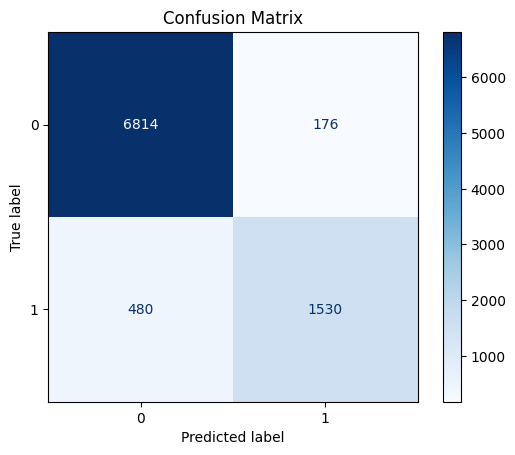

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.90      0.76      0.82      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.92      9000



In [44]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# make predictions
y_pred = model.predict(X_test)

# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# print classification report
print(classification_report(y_test, y_pred))

 Feature Importance

i tried to find which factors  model rely on most when deciding to approve or deny

In [47]:
# feature names
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

#  feature importance values
importances = model.named_steps['classifier'].feature_importances_

# ccombine
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 10 most important features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

# make clean  labelss
feature_importance['Feature'] = (feature_importance['Feature']
    .str.replace('cat__', '')
    .str.replace('num__', '')
    .str.replace('person_', '')
    .str.replace('_', ' ')
    .str.title())
print(feature_importance)

                               Feature  Importance
24                 Loan Percent Income    0.180182
17   Previous Loan Defaults On File No    0.158629
23                       Loan Int Rate    0.153703
18  Previous Loan Defaults On File Yes    0.143897
20                              Income    0.102286
10                 Home Ownership Rent    0.041689
22                           Loan Amnt    0.041675
26                        Credit Score    0.038495
7              Home Ownership Mortgage    0.022965
19                                 Age    0.017384


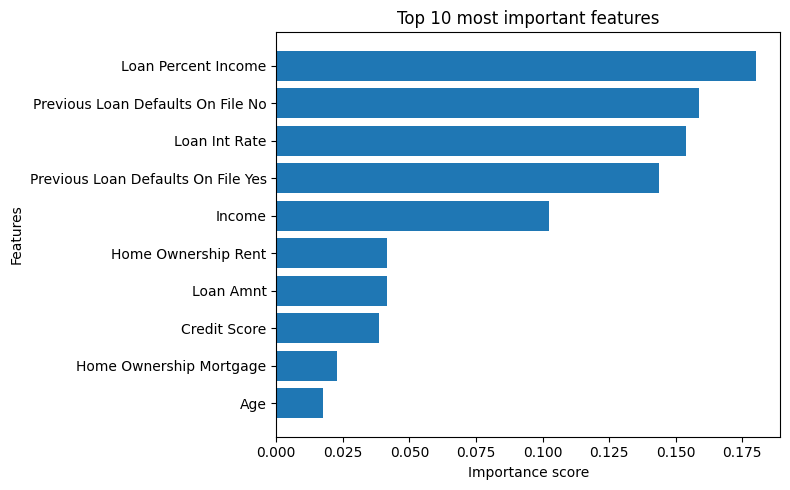

In [48]:
# plot  top 10
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.xlabel("Importance score")
plt.ylabel("Features")
plt.title("Top 10 most important features")

plt.tight_layout()
plt.show()

 so we can see at the top 3 which matter most

 if someone has poor grade the model almost always says no.  biggest risk for  bank is approving someone who defaults so when  model is unsuree it plays it safe and denies. best way is auto-approve  obvious good ones, auto-deny  obvious bad ones and check  unclear cases manually

this analysuis helps  bank decide which loan applications to approve automatically and which ones need  humanm to review

